# Shadowing function and its relevance in the radiation force

This notebook gives an example on how to use the shadowing function in order to achieve a realistic physical approach while using the Radiation force. Let's create a static simulation to show its use: 

In [1]:
import rebound
import reboundx
import numpy as np
import matplotlib.pyplot as plt

m_sun = 1.989e30
m_earth = 5.972e24
Rsun = 6.957e8
Rearth = 6.371e6
c_light_au_s = 3e8 / 1.496e11  # AU/s

Now we define the static simulation. The idea is to compare the two different shadow functions implemented in `rf.params["shadow_model"]`. There are three permitted inputs: 

1.  `rf.params["shadow_model"] = 0`: Is related to a non-shadowing-function, in order to maintain the previous logic in the radiation_force model. 

2. `rf.params["shadow_model"] = 1`: Is used for the cylindrical model, the simplest one, as it supposes that all shadows are infinite cylinders.

3. `rf.params["shadow_model"] = 2`: Belongs to the conical model, the sophisticated one. 

In [ ]:
def static_test():
    y = np.linspace(-0.1, 0.1, 100)  
    accelerations = {1: [], 2: []}

    for shadow_flag in [1, 2]: 

        sim = rebound.Simulation()
        sim.units = ('AU', 's', 'kg')
        rebx = reboundx.Extras(sim)
        sim.integrator = "leapfrog"
        sim.gravity = "none"
        
        rf = rebx.load_force("radiation_forces")
        rf.params["c"] = c_light_au_s  
        rf.params["shadow_model"] = shadow_flag  # 1 = Cylindrical, 2 = Conical

        # 0. Light source (Sun)
        sim.add(m=m_sun, x=0.0, y=0.0, z=0.0, hash= "Sun")
        Sun = sim.particles[0]
        Sun.params["radiation_source"] = 1
        Sun.params["R_eq"] = 0.1

        # 1. Occulting body (Earth)
        sim.add(m=m_earth, x=1.0, y=0.0, z=0.0, hash= "Earth")
        Earth = sim.particles[1]
        Earth.params["shadow_creator"] = 1
        Earth.params["R_eq"] = 0.01

        # 2. Particle (Dust)
        sim.add(m=0.0, x=1.05, y=0.0, z=0.0, hash= "Dust")
        Dust = sim.particles[2]
        Dust.params["beta"] = 0.1

        rebx.add_force(rf)

        for y_pos in y:
            Dust.x, Dust.y, Dust.z = 1.05, y_pos, 0.0
            Dust.vx, Dust.vy, Dust.vz = 0.0, 0.0, 0.0          
            sim.step()            
            accelerations[shadow_flag].append(sim.particles["Dust"].ax)

    plt.figure()
    plt.plot(y, accelerations[1], label="Cylindrical Model", color= 'blue')
    plt.plot(y, accelerations[2], label='Conical Model', color='red')
    plt.xlabel("Position Y (AU)")
    plt.ylabel("Acceleration X (AU/s²)")
    plt.title("Shadow effects on acceleration at a dust particle")
    plt.legend()
    plt.show()


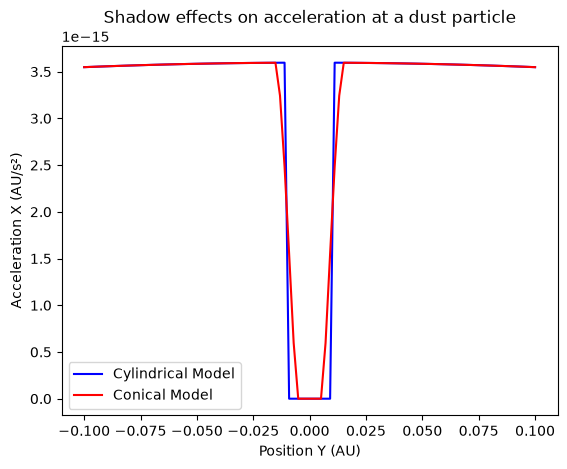

In [7]:
static_test()

With this figure, we can understand the difference between models, how the cylindrical is the so-called "step function" while the conical is much smoother, and how the shadows affect particles. 